Import Required Libraries



First, we import the libraries that we will need for working with the dataset, training the machine learning models, and checking their performance.

Here, Pandas is used to read and work with the dataset, NumPy works with numbers, and Scikit-learn is used for machine learning. Train-test split divides the data into training and testing parts, while StandardScaler puts the data into a similar range. The different models are used to predict heart disease, and the evaluation metrics are used to check how well the models perform.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


Load the Dataset

Here, we load the heart disease dataset and check its basic information before using it for machine learning.

In [2]:
# Load the dataset
data = pd.read_csv("dataset.csv")

# Display the first 5 rows
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Separate Features and Target

Here, we separate the input features from the target column. The features are the information about the patient, while the target tells us whether the person has heart disease or not.

In [3]:
# Separate features and target
X = data.drop("target", axis=1)
y = data["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


Remove duplicate rows

Here, we check for duplicate rows and remove them if there are any, so that the same patient data is not used more than once.

In [4]:
# Check for duplicate rows
print("Duplicate rows:", data.duplicated().sum())

# Remove duplicate rows
data = data.drop_duplicates()

print("Dataset shape after removing duplicates:", data.shape)

Duplicate rows: 1
Dataset shape after removing duplicates: (302, 14)


Because we changed data, we need to create X and y again:

In [5]:
# Separate features and target again
X = data.drop("target", axis=1)
y = data["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (302, 13)
Target shape: (302,)


Split the Data into Training and Testing Sets

Here, we split the dataset into training and testing parts. The training data is used to teach the model, while the testing data is used to check how well the model works on new data.

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (241, 13)
Testing data: (61, 13)


Feature Scaling

Here, we scale the features so that they are on a similar range. This is important for models like KNN and Logistic Regression because they are affected by the size of the feature values.

In [7]:
# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform testing data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


Logistic Regression

Here, we train a Logistic Regression model to predict whether a person has heart disease or not. We use the scaled training data to train the model and then test it on the testing data.

In [8]:
# Create the Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


K-Nearest Neighbors (KNN)

Here, we use KNN to predict heart disease by looking at the most similar patients in the dataset. We use the scaled data because KNN depends on the distance between data points.

In [9]:
# Create the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN model trained successfully.")

KNN model trained successfully.


Decision Tree

Here, we use a Decision Tree to predict heart disease by making a series of simple decisions based on the patient's features. Unlike KNN, this model does not require feature scaling.

In [10]:
# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Random Forest

Here, we use Random Forest to predict heart disease using multiple decision trees. The final prediction is made by combining the results from these trees.

In [11]:
# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Naive Bayes

Here, we use Naive Bayes to predict heart disease using probability. It calculates how likely a patient is to belong to each class and then gives the most likely result.

In [12]:
# Create the Naive Bayes model
naive_bayes_model = GaussianNB()

# Train the model
naive_bayes_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_nb = naive_bayes_model.predict(X_test_scaled)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


Evaluate the Models

Here, we evaluate the performance of all five machine learning models using accuracy, precision, recall, and F1-score. These metrics help us understand how well each model predicts heart disease.

 **Accuracy** → How many predictions were correct  
 **Precision** → How many predicted heart-disease cases were actually positive  
 **Recall** → How many actual heart-disease cases were correctly found  
**F1-score** → Balance between precision and recall

In [13]:
# Store all model predictions
predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb
}

# Calculate performance metrics
results = []

for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create a results table
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.786885,0.763158,0.878788,0.816901
1,KNN,0.803279,0.769231,0.909091,0.833333
2,Decision Tree,0.721311,0.710526,0.818182,0.760563
3,Random Forest,0.786885,0.750000,0.909091,0.821918
4,Naive Bayes,0.819672,0.789474,0.909091,0.845070


From the results, Naive Bayes performed the best among the five models with an accuracy of 81.97% and an F1-score of 84.51%. KNN was the second-best model based on accuracy and F1-score. Decision Tree had the lowest performance among the five models.

Confusion Matrix

Here, we create confusion matrices for all five models. A confusion matrix shows the correct and incorrect predictions made by each model.

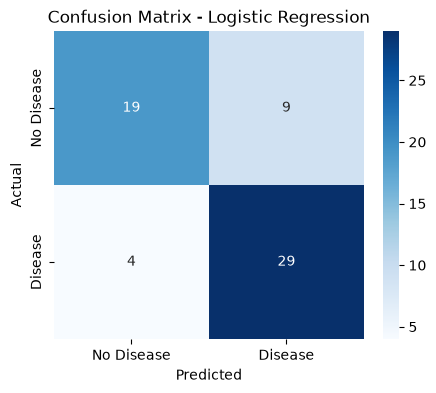

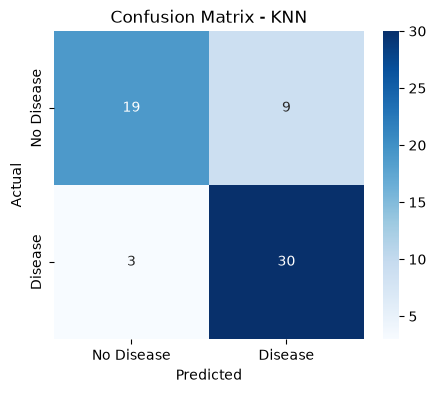

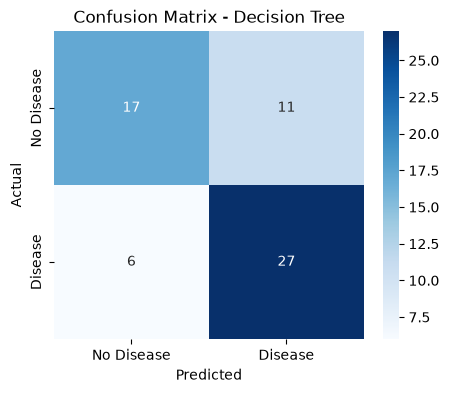

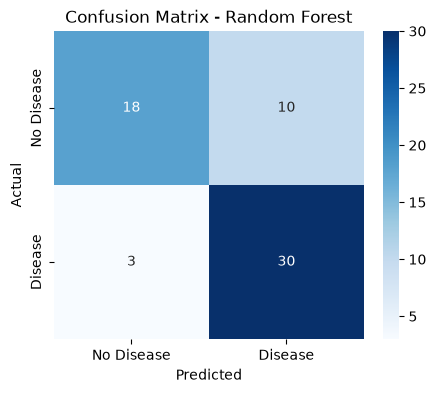

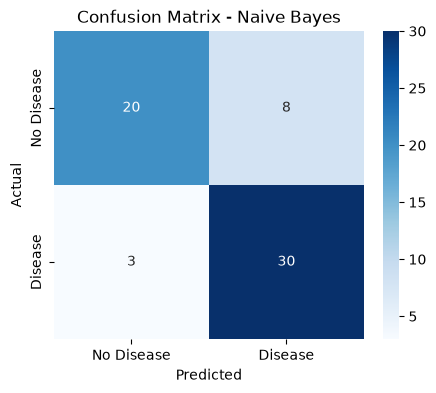

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Store the models and their predictions
model_predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb
}

# Create confusion matrices
for model_name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Compare the Models with a Graph 

Here, we compare the performance of all five models using their accuracy, precision, recall, and F1-score. This makes it easier to see which model performed better.

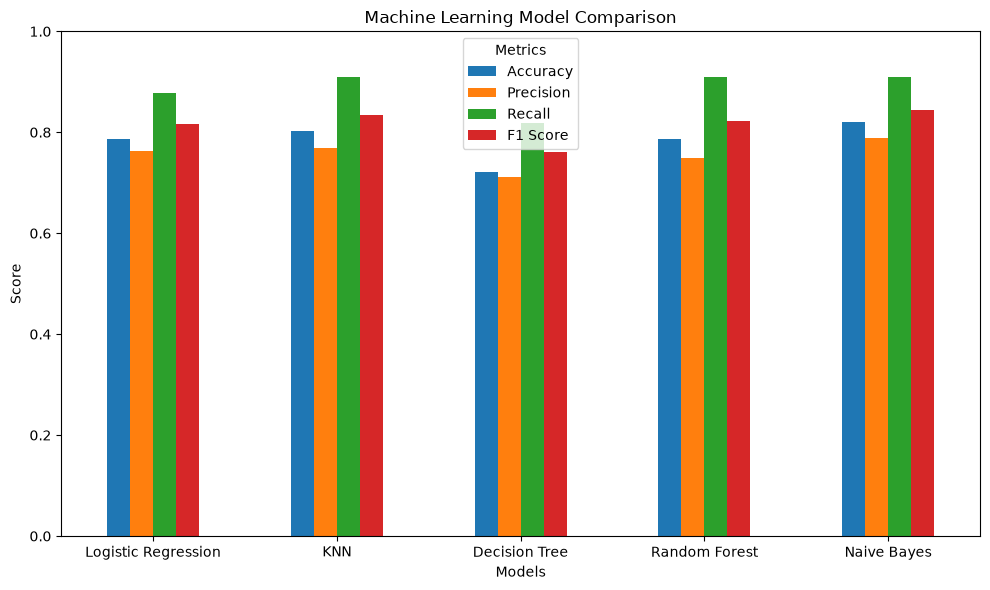

In [15]:
# Set the model name as the index
results_plot = results_df.set_index("Model")

# Plot the performance of all models
results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

Select the Best Model

Based on the evaluation results, we select the model with the highest F1-score as our best model. F1-score is useful here because it considers both precision and recall.

In [16]:
# Find the model with the highest F1-score
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

best_f1_score = results_df["F1 Score"].max()

print("Best Model:", best_model_name)
print("Best F1 Score:", round(best_f1_score, 4))

Best Model: Naive Bayes
Best F1 Score: 0.8451


Save the Best Model and Scaler

Here, we save the best-performing model and the scaler so that they can be used later in the prediction system without training the model again.

In [17]:
import joblib

# Save the best model
joblib.dump(naive_bayes_model, "best_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Best model and scaler saved successfully.")

Best model and scaler saved successfully.


We trained five different machine learning models to predict heart disease and compared their performance using accuracy, precision, recall, and F1-score. Among the five models, Naive Bayes performed the best with an accuracy of 81.97% and an F1-score of 84.51%. The trained Naive Bayes model and scaler were also saved so they can be used later in the prediction system.

Test the Saved Model

Here, we load the saved model and scaler again to make sure they were saved correctly and can be used for making predictions later.

In [18]:
# Load the saved model and scaler
loaded_model = joblib.load("best_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Use the loaded scaler on the test data
X_test_loaded = loaded_scaler.transform(X_test)

# Make predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test_loaded)

print("Saved model loaded successfully!")
print("Predictions generated successfully!")

Saved model loaded successfully!
Predictions generated successfully!
